# Data analysis
1. Summary statistics
2. Regression table
3. Histogram chart

### Set code parameters

In [9]:
# Libraries
# Data handling
import pandas as pd
import numpy as np

# Regression
import statsmodels.formula.api as smf # For regression table outputs
from stargazer.stargazer import Stargazer # For tables display and output

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Paths
# interim_path = '../data/interim'
# raw_path = '../data/raw'
processed_path = '../data/processed'
reports = '../reports'
figures = f'{reports}/figures'

## 1. Summary statistics

In [7]:
# Load data for analysis
df = pd.read_csv(f"{processed_path}/TZA_CCT_analysis.csv")
df.head()

,vid,hhid,enid,treatment,district,district_name,floor,roof,walls,water,...,trust_mem,trust_lead,assoc,health,duration,submissionday,key,area_acre,food_cons_usd,nonfood_cons_usd
0,1,9101,828,0,2,Bagamoyo,1,2,5,5,...,0.0,1.0,1.0,1.0,78,2009-02-28 10:41:05,NgE1000979iaH,1.500000,102.9210,37.9392
1,1,9102,805,0,2,Bagamoyo,1,2,1,7,...,1.0,1.0,0.0,0.0,100,2009-02-27 14:47:54,LlC1900619MRg,3.326588,203.3070,16.2630
2,1,9103,823,0,2,Bagamoyo,1,2,1,1,...,0.0,1.0,NaN,0.0,89,2009-02-27 16:17:08,XzQ1000817FbT,0.750000,166.8030,21.7230
3,1,9104,621,0,2,Bagamoyo,1,2,5,2,...,0.0,1.0,0.0,1.0,99,2009-02-27 12:17:57,Fyn1564708enK,2.772157,200.7720,45.9420
4,1,9105,805,0,2,Bagamoyo,1,2,1,7,...,1.0,1.0,0.0,0.0,83,2009-02-27 12:57:43,BNa1418306uSF,0.750000,290.3082,14.6640


In [17]:
# Summary statistics.
# Manual creation
district_stats = df[['district_name','hh_size', 'n_child_5','area_acre', 'food_cons_usd','crop_damage']].\
    groupby(['district_name']).\
    agg([('mean', np.mean), 
         ('std',np.std)])

# Save results
district_stats.to_csv(f'{reports}/summary_by_district.csv', index = False)

# Print summary
print(district_stats)

                hh_size           n_child_5           area_acre            \
                   mean       std      mean       std      mean       std   
district_name                                                               
Bagamoyo       4.339402  2.844111  0.508453  0.844315  1.785767  1.529166   
Chamwino       4.132673  2.610759  0.469307  0.780675  1.786253  1.544284   
Kibaha         3.245868  1.982226  0.402893  0.725048  1.699218  1.438217   

              food_cons_usd             crop_damage            
                       mean         std        mean       std  
district_name                                                  
Bagamoyo         296.824372  173.071235    0.565670  0.495669  
Chamwino         254.562421  166.356573    0.570297  0.495034  
Kibaha           137.186239  107.678859    0.390496  0.487862  


# 2. Regression table

In [5]:
print("Data variables:\n", df.columns)

Data variables:
 Index(['vid', 'hhid', 'enid', 'treatment', 'district', 'district_name',
       'floor', 'roof', 'walls', 'water', 'enegry', 'rel_head', 'female_head',
       'hh_size', 'n_child_5', 'n_child_17', 'n_adult', 'n_elder', 'read',
       'sick', 'food_cons', 'nonfood_cons', 'farm', 'ar_farm', 'ar_farm_unit',
       'crop', 'crop_other', 'crop_prp', 'livestock_now', 'livestock_before',
       'drought_flood', 'crop_damage', 'trust_mem', 'trust_lead', 'assoc',
       'health', 'duration', 'submissionday', 'key', 'area_acre',
       'food_cons_usd', 'nonfood_cons_usd'],
      dtype='str')


In [6]:
# Run regressions using statsmodels
model1 = smf.ols('food_cons_usd ~ treatment', data = df).fit()
model2 = smf.ols('food_cons_usd ~ treatment + crop_damage', data = df).fit()
model3 = smf.ols('food_cons_usd ~ treatment + crop_damage + drought_flood', data = df).fit()
model4 = smf.ols('food_cons_usd ~ treatment + crop_damage + drought_flood + area_acre', data = df).fit()
model5 = smf.ols('food_cons_usd ~ treatment + crop_damage + drought_flood + area_acre + nonfood_cons_usd', data = df).fit()

# Pass the models to Stargazer
stargazer = Stargazer([model1, model2, model3, model4, model5])

# Customizations (just like esttab/outreg)
stargazer.custom_columns(['Base Model', 'crop control', 'crop-drought control', 'crop-drought-area control', 'crop-drought-area-nonfood control'])
# stargazer.show_model_numbers(True)
stargazer.significant_digits(2)
display(stargazer)

# Render the output
#stargazer.render_html() # Renders nicely in Jupyter Notebooks
# print(stargazer.render_latex()) # Outputs LaTeX code for your paper

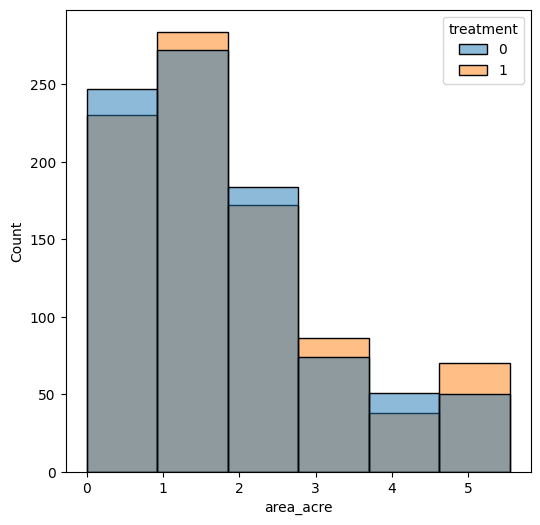

In [ ]:
plt.figure(figsize = [6,6])
sns.histplot(data = df, x = 'area_acre', hue = 'treatment', binwidth= 0.9)
plt.savefig(f'{figures}/treatment_histogram.png')
plt.show()

In [19]:
df[df['treatment']==1].value_counts(['area_acre'])

area_acre
1.000000     213
2.000000     154
0.500000      95
3.326588      82
5.544314      69
0.000000      67
1.500000      62
0.250000      41
4.435451      35
2.772157      13
0.750000       9
0.300000       8
1.250000       6
2.550384       4
3.881020       3
0.800000       3
3.049373       3
0.200000       3
0.125000       2
1.750000       2
0.400000       2
4.989883       1
3.603804       1
2.494941       1
1.300000       1
Name: count, dtype: int64